<a href="https://colab.research.google.com/github/aashi-singh-web/ML-LAB-CS/blob/main/ML_LAB8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
wdbc_columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

In [4]:
df = pd.read_csv("/content/wdbc.data", header=None, names=wdbc_columns)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
X = df.drop(columns=['id', 'diagnosis'])

In [6]:
df['diagnosis_encoded'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA Explained Variance (2 components): {pca.explained_variance_ratio_.sum():.2%}")


PCA Explained Variance (2 components): 63.24%


In [9]:
def evaluate(name, labels, X):
    mask = labels != -1  # exclude DBSCAN noise
    unique_labels = np.unique(labels[mask])
    if len(unique_labels) < 2:
        print(f"{name}: Not enough clusters to evaluate.")
        return
    sil = silhouette_score(X[mask], labels[mask])
    db  = davies_bouldin_score(X[mask], labels[mask])
    noise_pts = np.sum(labels == -1)
    print(f"\n{'─'*45}")
    print(f" {name}")
    print(f"{'─'*45}")
    print(f"  Clusters found     : {len(unique_labels)}")
    if noise_pts > 0:
        print(f"  Noise points       : {noise_pts}")
    print(f"  Silhouette Score   : {sil:.4f}  (higher = better, max 1)")
    print(f"  Davies-Bouldin Idx : {db:.4f}  (lower  = better, min 0)")

In [10]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = km_labels
evaluate("K-Means Clustering", km_labels, X_scaled)


─────────────────────────────────────────────
 K-Means Clustering
─────────────────────────────────────────────
  Clusters found     : 2
  Silhouette Score   : 0.3434  (higher = better, max 1)
  Davies-Bouldin Idx : 1.3205  (lower  = better, min 0)


**Agglomerative CLustering**

In [14]:
agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)
df['Agglomerative_Cluster'] = agglo_labels
evaluate("Agglomerative Clustering (Ward)", agglo_labels, X_scaled)


─────────────────────────────────────────────
 Agglomerative Clustering (Ward)
─────────────────────────────────────────────
  Clusters found     : 2
  Silhouette Score   : 0.3394  (higher = better, max 1)
  Davies-Bouldin Idx : 1.3700  (lower  = better, min 0)


**DBSCAN**

In [15]:
dbscan = DBSCAN(eps=3.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = db_labels
evaluate("DBSCAN", db_labels, X_scaled)

DBSCAN: Not enough clusters to evaluate.


**DIANA**

In [16]:
def diana(X, n_clusters=2):
    """
    DIANA (DIvisive ANAlysis) clustering.
    Starts with all points in one cluster, then recursively splits
    the cluster with the largest diameter (max pairwise distance).
    """
    from sklearn.metrics import pairwise_distances

    n_samples = X.shape[0]
    clusters = [list(range(n_samples))]

    while len(clusters) < n_clusters:
        # Find cluster with the largest diameter
        diameters = []
        for cluster in clusters:
            if len(cluster) < 2:
                diameters.append(0)
            else:
                D = pairwise_distances(X[cluster], metric='euclidean')
                diameters.append(D.max())

        split_idx = int(np.argmax(diameters))
        cluster_to_split = clusters[split_idx]

        if len(cluster_to_split) < 2:
            break

        sub = X[cluster_to_split]
        D = pairwise_distances(sub, metric='euclidean')

        # Most dissimilar point starts the splinter group
        avg_dist = D.mean(axis=1)
        splinter_local_idx = int(np.argmax(avg_dist))

        splinter_group = [cluster_to_split[splinter_local_idx]]
        remaining = [p for i, p in enumerate(cluster_to_split) if i != splinter_local_idx]

        # Move points closer to splinter group into it
        moved = True
        while moved:
            moved = False
            new_remaining = []
            for p in remaining:
                d_splinter = np.mean([np.linalg.norm(X[p] - X[s]) for s in splinter_group])
                others = [r for r in remaining if r != p]
                d_remaining = np.mean([np.linalg.norm(X[p] - X[o]) for o in others]) if others else float('inf')
                if d_splinter < d_remaining:
                    splinter_group.append(p)
                    moved = True
                else:
                    new_remaining.append(p)
            remaining = new_remaining

        clusters.pop(split_idx)
        if remaining:
            clusters.append(remaining)
        if splinter_group:
            clusters.append(splinter_group)

    labels = np.full(n_samples, -1, dtype=int)
    for label, cluster in enumerate(clusters):
        for idx in cluster:
            labels[idx] = label
    return labels

In [17]:
print("\nRunning DIANA (may take ~30 seconds for 569 samples)...")
diana_labels = diana(X_scaled, n_clusters=2)
df['DIANA_Cluster'] = diana_labels
evaluate("DIANA (Divisive Analysis)", diana_labels, X_scaled)


Running DIANA (may take ~30 seconds for 569 samples)...

─────────────────────────────────────────────
 DIANA (Divisive Analysis)
─────────────────────────────────────────────
  Clusters found     : 2
  Silhouette Score   : 0.3702  (higher = better, max 1)
  Davies-Bouldin Idx : 1.2720  (lower  = better, min 0)


**DENDROGRAM**

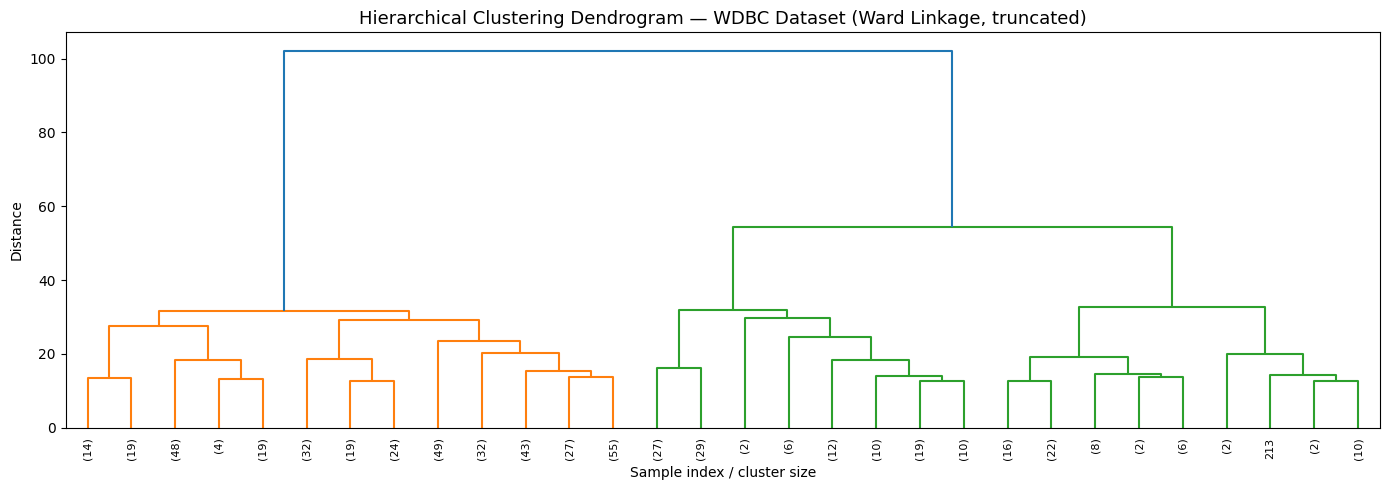

In [18]:
plt.figure(figsize=(14, 5))
linked = linkage(X_scaled, method='ward')
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title("Hierarchical Clustering Dendrogram — WDBC Dataset (Ward Linkage, truncated)", fontsize=13)
plt.xlabel("Sample index / cluster size")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [19]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

configs = [
    ("K-Means Clustering",              km_labels,    'viridis', gs[0, 0]),
    ("Agglomerative Clustering (Ward)", agglo_labels, 'plasma',  gs[0, 1]),
    ("DBSCAN",                          db_labels,    'tab10',   gs[1, 0]),
    ("DIANA (Divisive Analysis)",       diana_labels, 'cool',    gs[1, 1]),
]

<Figure size 1800x1400 with 0 Axes>

In [20]:
for title, labels, cmap, pos in configs:
    ax = fig.add_subplot(pos)
    noise_mask = labels == -1

    if noise_mask.any():
        ax.scatter(
            X_pca[noise_mask, 0], X_pca[noise_mask, 1],
            c='lightgrey', s=20, label='Noise', zorder=1, alpha=0.6
        )

    sc = ax.scatter(
        X_pca[~noise_mask, 0], X_pca[~noise_mask, 1],
        c=labels[~noise_mask], cmap=cmap,
        s=30, alpha=0.8, edgecolors='k', linewidths=0.3, zorder=2
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("PC 1", fontsize=9)
    ax.set_ylabel("PC 2", fontsize=9)
    plt.colorbar(sc, ax=ax, label='Cluster')
    if noise_mask.any():
        ax.legend(fontsize=7)

fig.suptitle(
    "WDBC Breast Cancer Dataset — Clustering Comparison (PCA 2D Projection)",
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4564/1231958179.py:19: UserWarning: Adding colorbar to a different Figure <Figure size 1800x1400 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, ax=ax, label='Cluster')
/tmp/ipykernel_4564/1231958179.py:19: UserWarning: Adding colorbar to a different Figure <Figure size 1800x1400 with 4 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, ax=ax, label='Cluster')
/tmp/ipykernel_4564/1231958179.py:19: UserWarning: Adding colorbar to a different Figure <Figure size 1800x1400 with 6 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, ax=ax, label='Cluster')
/tmp/ipykernel_4564/1231958179.py:19: UserWarning: Adding colorbar to a different Figure <Figure size 1800x1400 with 8 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, ax=ax, label='Cluster')


<Figure size 640x480 with 0 Axes>

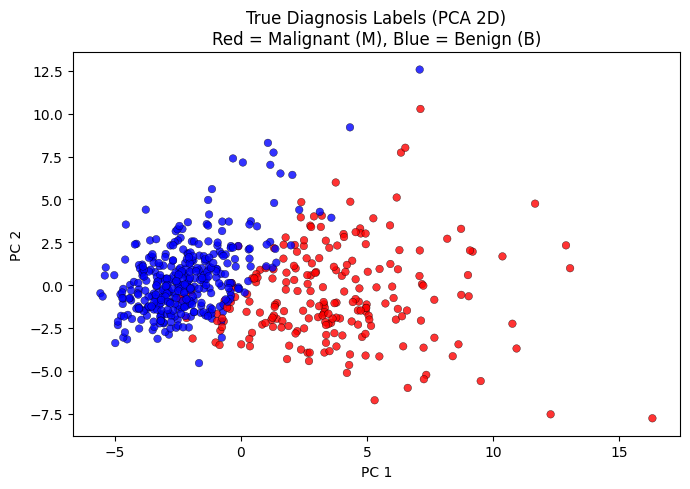

In [21]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df['diagnosis_encoded'], cmap='bwr',
    s=30, alpha=0.8, edgecolors='k', linewidths=0.3
)
plt.title("True Diagnosis Labels (PCA 2D)\nRed = Malignant (M), Blue = Benign (B)", fontsize=12)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

In [22]:
print("\n" + "="*55)
print(" CLUSTERING SUMMARY — WDBC BREAST CANCER DATASET")
print("="*55)

summary_rows = []
for name, labels in [
    ("K-Means",       km_labels),
    ("Agglomerative", agglo_labels),
    ("DBSCAN",        db_labels),
    ("DIANA",         diana_labels),
]:
    mask = labels != -1
    unique = np.unique(labels[mask])
    if len(unique) < 2:
        summary_rows.append({
            "Algorithm": name,
            "Clusters": len(unique),
            "Noise Pts": int(np.sum(labels == -1)),
            "Silhouette": "N/A",
            "Davies-Bouldin": "N/A"
        })
    else:
        summary_rows.append({
            "Algorithm": name,
            "Clusters": len(unique),
            "Noise Pts": int(np.sum(labels == -1)),
            "Silhouette": round(silhouette_score(X_scaled[mask], labels[mask]), 4),
            "Davies-Bouldin": round(davies_bouldin_score(X_scaled[mask], labels[mask]), 4)
        })

summary_df = pd.DataFrame(summary_rows).set_index("Algorithm")
print(summary_df.to_string())
print("\nFull DataFrame with cluster labels (first 5 rows):")
print(df[['id', 'diagnosis', 'KMeans_Cluster', 'Agglomerative_Cluster',
          'DBSCAN_Cluster', 'DIANA_Cluster']].head())


 CLUSTERING SUMMARY — WDBC BREAST CANCER DATASET
               Clusters  Noise Pts Silhouette Davies-Bouldin
Algorithm                                                   
K-Means               2          0     0.3434         1.3205
Agglomerative         2          0     0.3394           1.37
DBSCAN                1         75        N/A            N/A
DIANA                 2          0     0.3702          1.272

Full DataFrame with cluster labels (first 5 rows):
         id diagnosis  KMeans_Cluster  Agglomerative_Cluster  DBSCAN_Cluster  \
0    842302         M               1                      0              -1   
1    842517         M               1                      0               0   
2  84300903         M               1                      0               0   
3  84348301         M               1                      0              -1   
4  84358402         M               1                      0               0   

   DIANA_Cluster  
0              1  
1            